# Stack Overflow Developer Survey 2025
## Notebook 2 — Salary Regression Pipelines

**Research question:** After controlling for experience, region, DevType, industry, and tech stack — how much of the salary variance does `UsesAI` explain?

**Target:** `log_salary` (log-transformed, outlier-capped `ConvertedCompYearly`)

**Three independent pipelines:**

| Pipeline | Model | Scaling needed? |
|---|---|---|
| 1 | Linear Regression (baseline) | Yes — WorkExp must be scaled |
| 2 | Random Forest Regressor | No — tree-based, scale-invariant |
| 3 | XGBoost Regressor | No — tree-based, scale-invariant |

**Workflow per pipeline:**
```
X_reg_train / y_reg_train  (loaded from Notebook 1 artefacts)
│
└── 5-Fold KFold CV  →  CV MAE / CV R²  →  comparison table
         │
         └── Winner selected → retrained on full X_reg_train
                  │
                  └── Final evaluation on X_reg_test (ONCE)
                           │
                           └── SHAP analysis → UsesAI marginal effect
```

In [1]:
class Config:
    DATA_DIR     = './data/'
    RESULTS_DIR  = './results/regression/'
    MODELS_DIR   = './models/regression/'
    RANDOM_STATE = 42
    N_FOLDS      = 5
    CONTINUOUS_COLS = ['WorkExp']

config = Config()
print('Config loaded.')

Config loaded.


In [4]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import StandardScaler
from sklearn.linear_model        import LinearRegression, Ridge
from sklearn.ensemble            import RandomForestRegressor
from sklearn.model_selection     import KFold, cross_validate
from sklearn.metrics             import mean_absolute_error, r2_score, mean_squared_error
from xgboost                     import XGBRegressor
import joblib
import shap

SEED = config.RANDOM_STATE
np.random.seed(SEED)

os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.MODELS_DIR,  exist_ok=True)

print('Imports complete.')

Imports complete.


## LOAD SPLIT ARTEFACTS

Loads the exact train/test split produced by Notebook 1. No re-splitting.

In [5]:
X_train = pd.read_parquet(os.path.join(config.DATA_DIR, 'X_reg_train.parquet'))
X_test  = pd.read_parquet(os.path.join(config.DATA_DIR, 'X_reg_test.parquet'))
y_train = pd.read_parquet(os.path.join(config.DATA_DIR, 'y_reg_train.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(config.DATA_DIR, 'y_reg_test.parquet')).squeeze()

print('Loaded from Notebook 1 artefacts:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}  [LOCKED until final evaluation]')
print(f'  y_train : {y_train.shape}  mean={y_train.mean():.4f}  std={y_train.std():.4f}')
print(f'  y_test  : {y_test.shape}')
print(f'\n  UsesAI in X_train: {"UsesAI" in X_train.columns}  ← should be True')

assert 'UsesAI' in X_train.columns, 'UsesAI must be in the regression feature set'
assert 'log_salary' not in X_train.columns, 'Target leakage: log_salary in features'
print('  Assertions passed.')

Loaded from Notebook 1 artefacts:
  X_train : (14411, 103)
  X_test  : (3603, 103)  [LOCKED until final evaluation]
  y_train : (14411,)  mean=11.0141  std=1.1584
  y_test  : (3603,)

  UsesAI in X_train: True  ← should be True
  Assertions passed.


## Design rationale

WorkExp is the only continuous feature — scaling it prevents Ridge from over-penalising it relative to binary columns. Binary columns are passed through unchanged; standardising them would distort their 0/1 interpretation. The preprocessor is fitted inside the Pipeline to ensure it sees only training-fold data during cross-validation.

In [6]:
# ── Preprocessing: scale WorkExp only, passthrough binary cols ─────────────
binary_cols = [c for c in X_train.columns if c not in config.CONTINUOUS_COLS]

preprocessor_with_scaling = ColumnTransformer([
    ('scale', StandardScaler(), config.CONTINUOUS_COLS),
    ('passthrough', 'passthrough', binary_cols)
])

preprocessor_passthrough = ColumnTransformer([
    ('passthrough', 'passthrough', X_train.columns.tolist())
])

# ── Pipeline 1: Linear Regression (Ridge for numerical stability) ──────────
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_with_scaling),
    ('model', Ridge(random_state=SEED))
])

# ── Pipeline 2: Random Forest Regressor ───────────────────────────────────
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=4,
        random_state=SEED,
        n_jobs=-1
    ))
])

# ── Pipeline 3: XGBoost Regressor ─────────────────────────────────────────
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    ))
])

PIPELINES = {
    'Linear Regression (Ridge)': pipeline_lr,
    'Random Forest'            : pipeline_rf,
    'XGBoost'                  : pipeline_xgb,
}

print('Pipelines defined:')
for name in PIPELINES:
    print(f'  {name}')

Pipelines defined:
  Linear Regression (Ridge)
  Random Forest
  XGBoost


## Linear Regression (Ridge)

In [7]:
print('Running Pipeline 1: Linear Regression (Ridge) — 5-Fold CV')
print('-' * 55)

kf = KFold(n_splits=config.N_FOLDS, shuffle=True, random_state=SEED)

cv_lr = cross_validate(
    pipeline_lr, X_train, y_train,
    cv=kf,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2'     : 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

lr_results = {
    'cv_mae'       : -cv_lr['test_neg_mae'].mean(),
    'cv_mae_std'   : cv_lr['test_neg_mae'].std(),
    'cv_r2'        : cv_lr['test_r2'].mean(),
    'cv_r2_std'    : cv_lr['test_r2'].std(),
    'train_mae'    : -cv_lr['train_neg_mae'].mean(),
    'train_r2'     : cv_lr['train_r2'].mean(),
    'fold_maes'    : (-cv_lr['test_neg_mae']).tolist(),
    'fold_r2s'     : cv_lr['test_r2'].tolist()
}

print(f"  CV MAE (log scale) : {lr_results['cv_mae']:.4f}  ±{lr_results['cv_mae_std']:.4f}")
print(f"  CV R²              : {lr_results['cv_r2']:.4f}  ±{lr_results['cv_r2_std']:.4f}")
print(f"  Train MAE          : {lr_results['train_mae']:.4f}  (gap={lr_results['cv_mae']-lr_results['train_mae']:.4f})")
print(f"  Train R²           : {lr_results['train_r2']:.4f}")
print(f"  Fold MAEs          : {[f'{v:.4f}' for v in lr_results['fold_maes']]}")

Running Pipeline 1: Linear Regression (Ridge) — 5-Fold CV
-------------------------------------------------------
  CV MAE (log scale) : 0.5589  ±0.0162
  CV R²              : 0.4197  ±0.0239
  Train MAE          : 0.5533  (gap=0.0056)
  Train R²           : 0.4315
  Fold MAEs          : ['0.5446', '0.5559', '0.5400', '0.5837', '0.5701']


## Random Forest Regressor

In [8]:
print('Running Pipeline 2: Random Forest Regressor — 5-Fold CV')
print('-' * 55)

cv_rf = cross_validate(
    pipeline_rf, X_train, y_train,
    cv=kf,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2'     : 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

rf_results = {
    'cv_mae'       : -cv_rf['test_neg_mae'].mean(),
    'cv_mae_std'   : cv_rf['test_neg_mae'].std(),
    'cv_r2'        : cv_rf['test_r2'].mean(),
    'cv_r2_std'    : cv_rf['test_r2'].std(),
    'train_mae'    : -cv_rf['train_neg_mae'].mean(),
    'train_r2'     : cv_rf['train_r2'].mean(),
    'fold_maes'    : (-cv_rf['test_neg_mae']).tolist(),
    'fold_r2s'     : cv_rf['test_r2'].tolist()
}

print(f"  CV MAE (log scale) : {rf_results['cv_mae']:.4f}  ±{rf_results['cv_mae_std']:.4f}")
print(f"  CV R²              : {rf_results['cv_r2']:.4f}  ±{rf_results['cv_r2_std']:.4f}")
print(f"  Train MAE          : {rf_results['train_mae']:.4f}  (gap={rf_results['cv_mae']-rf_results['train_mae']:.4f})")
print(f"  Train R²           : {rf_results['train_r2']:.4f}")
print(f"  Fold MAEs          : {[f'{v:.4f}' for v in rf_results['fold_maes']]}")

Running Pipeline 2: Random Forest Regressor — 5-Fold CV
-------------------------------------------------------
  CV MAE (log scale) : 0.5263  ±0.0138
  CV R²              : 0.4512  ±0.0216
  Train MAE          : 0.4706  (gap=0.0557)
  Train R²           : 0.5593
  Fold MAEs          : ['0.5122', '0.5236', '0.5128', '0.5486', '0.5342']


## XGBoost Regressor

In [9]:
print('Running Pipeline 3: XGBoost Regressor — 5-Fold CV')
print('-' * 55)

cv_xgb = cross_validate(
    pipeline_xgb, X_train, y_train,
    cv=kf,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2'     : 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

xgb_results = {
    'cv_mae'       : -cv_xgb['test_neg_mae'].mean(),
    'cv_mae_std'   : cv_xgb['test_neg_mae'].std(),
    'cv_r2'        : cv_xgb['test_r2'].mean(),
    'cv_r2_std'    : cv_xgb['test_r2'].std(),
    'train_mae'    : -cv_xgb['train_neg_mae'].mean(),
    'train_r2'     : cv_xgb['train_r2'].mean(),
    'fold_maes'    : (-cv_xgb['test_neg_mae']).tolist(),
    'fold_r2s'     : cv_xgb['test_r2'].tolist()
}

print(f"  CV MAE (log scale) : {xgb_results['cv_mae']:.4f}  ±{xgb_results['cv_mae_std']:.4f}")
print(f"  CV R²              : {xgb_results['cv_r2']:.4f}  ±{xgb_results['cv_r2_std']:.4f}")
print(f"  Train MAE          : {xgb_results['train_mae']:.4f}  (gap={xgb_results['cv_mae']-xgb_results['train_mae']:.4f})")
print(f"  Train R²           : {xgb_results['train_r2']:.4f}")
print(f"  Fold MAEs          : {[f'{v:.4f}' for v in xgb_results['fold_maes']]}")

Running Pipeline 3: XGBoost Regressor — 5-Fold CV
-------------------------------------------------------
  CV MAE (log scale) : 0.5279  ±0.0170
  CV R²              : 0.4511  ±0.0289
  Train MAE          : 0.4179  (gap=0.1100)
  Train R²           : 0.6668
  Fold MAEs          : ['0.5064', '0.5278', '0.5124', '0.5514', '0.5416']


## CV RESULTS COMPARISON TABLE

In [10]:
all_cv = {
    'Linear Regression (Ridge)': lr_results,
    'Random Forest'            : rf_results,
    'XGBoost'                  : xgb_results,
}

comparison_df = pd.DataFrame([
    {
        'Model'            : name,
        'CV MAE (avg)'     : f"{res['cv_mae']:.4f}",
        'CV MAE (±std)'    : f"{res['cv_mae_std']:.4f}",
        'CV R² (avg)'      : f"{res['cv_r2']:.4f}",
        'CV R² (±std)'     : f"{res['cv_r2_std']:.4f}",
        'Train MAE'        : f"{res['train_mae']:.4f}",
        'Train R²'         : f"{res['train_r2']:.4f}",
        'Overfit gap (MAE)': f"{res['cv_mae'] - res['train_mae']:.4f}",
    }
    for name, res in all_cv.items()
])

print('\n5-FOLD CV COMPARISON — SALARY REGRESSION')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)
print('\nReading guide:')
print('  Lower CV MAE = better predictive accuracy')
print('  Higher CV R² = more variance explained')
print('  Lower ±std   = more consistent across folds')
print('  Overfit gap  = (CV MAE - Train MAE); large gap → model memorising training data')

comparison_df.to_csv(os.path.join(config.RESULTS_DIR, 'cv_comparison.csv'), index=False)
print('\nComparison table saved.')


5-FOLD CV COMPARISON — SALARY REGRESSION
                    Model CV MAE (avg) CV MAE (±std) CV R² (avg) CV R² (±std) Train MAE Train R² Overfit gap (MAE)
Linear Regression (Ridge)       0.5589        0.0162      0.4197       0.0239    0.5533   0.4315            0.0056
            Random Forest       0.5263        0.0138      0.4512       0.0216    0.4706   0.5593            0.0557
                  XGBoost       0.5279        0.0170      0.4511       0.0289    0.4179   0.6668            0.1100

Reading guide:
  Lower CV MAE = better predictive accuracy
  Higher CV R² = more variance explained
  Lower ±std   = more consistent across folds
  Overfit gap  = (CV MAE - Train MAE); large gap → model memorising training data

Comparison table saved.


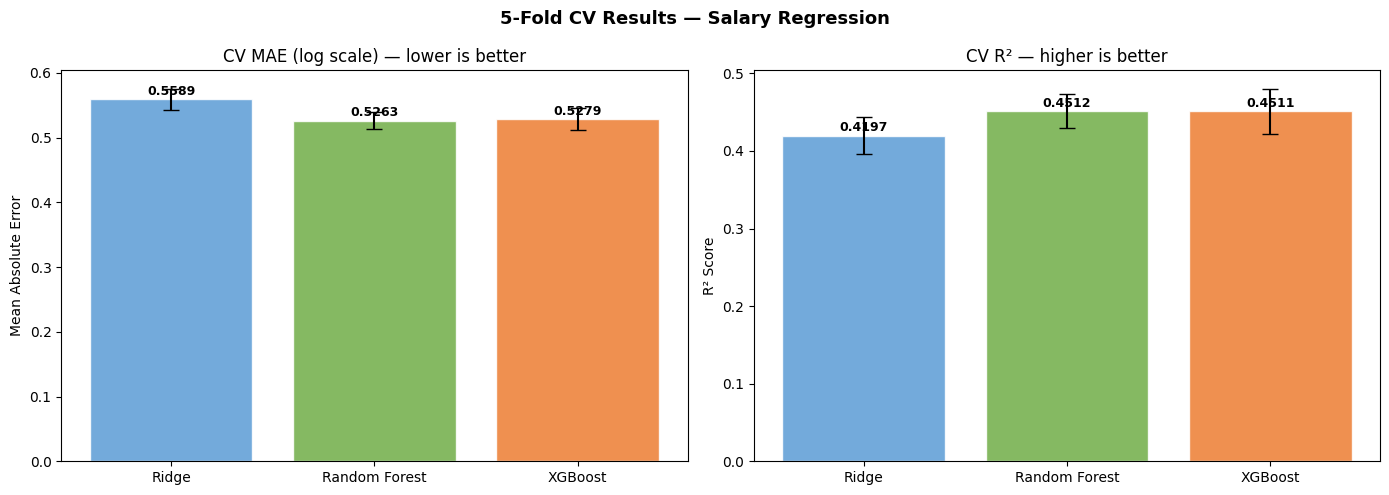

In [11]:
# ── Visualise CV fold results ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold CV Results — Salary Regression', fontsize=13, fontweight='bold')

model_names   = list(all_cv.keys())
short_names   = ['Ridge', 'Random Forest', 'XGBoost']
cv_maes       = [all_cv[n]['cv_mae']     for n in model_names]
cv_mae_stds   = [all_cv[n]['cv_mae_std'] for n in model_names]
cv_r2s        = [all_cv[n]['cv_r2']      for n in model_names]
cv_r2_stds    = [all_cv[n]['cv_r2_std']  for n in model_names]
colors        = ['#5B9BD5', '#70AD47', '#ED7D31']

# MAE bars
bars = axes[0].bar(short_names, cv_maes, yerr=cv_mae_stds, capsize=6,
                   color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('CV MAE (log scale) — lower is better')
axes[0].set_ylabel('Mean Absolute Error')
for bar, val in zip(bars, cv_maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# R² bars
bars2 = axes[1].bar(short_names, cv_r2s, yerr=cv_r2_stds, capsize=6,
                    color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('CV R² — higher is better')
axes[1].set_ylabel('R² Score')
for bar, val in zip(bars2, cv_r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'cv_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

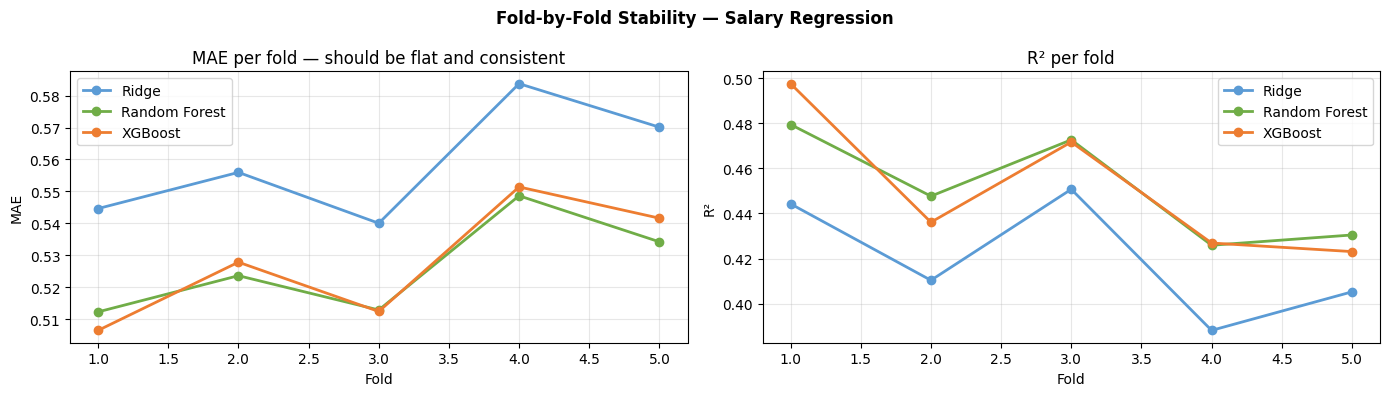

In [12]:
# ── Fold-by-fold stability plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Fold-by-Fold Stability — Salary Regression', fontsize=12, fontweight='bold')

fold_nums = list(range(1, config.N_FOLDS + 1))

for i, (name, short, color) in enumerate(zip(model_names, short_names, colors)):
    axes[0].plot(fold_nums, all_cv[name]['fold_maes'], marker='o', label=short, color=color, linewidth=2)
    axes[1].plot(fold_nums, all_cv[name]['fold_r2s'],  marker='o', label=short, color=color, linewidth=2)

axes[0].set_title('MAE per fold — should be flat and consistent')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('R² per fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'fold_stability.png'), dpi=150, bbox_inches='tight')
plt.show()

Overfit gap = CV MAE − Train MAE. A positive value means the model performs worse on held-out folds than on training data (expected). Larger positive values indicate more severe memorisation.

## MODEL SELECTION

Selection logic: primary metric is CV MAE (lower is better). If the gap between the best and second-best model falls within ±0.005 log-scale units, the tiebreaker is fold consistency (lower ±std). A model with marginally worse MAE but substantially lower variance is preferable for generalisation.

**Decision criteria (in order):**
1. CV MAE (lower is better)
2. If MAE difference < 0.005 → prefer lower std
3. If still tied → prefer higher R²

In [13]:
def select_best_regression_model(results_dict, pipelines_dict, tolerance=0.005):
    """
    Intelligent model selection.
    Primary  : lowest CV MAE
    Secondary: lowest MAE std (consistency), if primary metric within tolerance
    Tertiary : highest CV R²
    """
    candidates = pd.DataFrame([
        {
            'name'    : name,
            'cv_mae'  : res['cv_mae'],
            'mae_std' : res['cv_mae_std'],
            'cv_r2'   : res['cv_r2'],
            'r2_std'  : res['cv_r2_std'],
        }
        for name, res in results_dict.items()
    ]).sort_values('cv_mae')

    best_mae = candidates.iloc[0]['cv_mae']

    # Candidates within tolerance of the best MAE
    within_tol = candidates[candidates['cv_mae'] <= best_mae + tolerance]

    if len(within_tol) > 1:
        # Tiebreak on consistency (lower std preferred)
        winner_row = within_tol.sort_values(['mae_std', 'cv_mae']).iloc[0]
        reason = f'MAE within tolerance ({tolerance}); selected for lower std ({winner_row["mae_std"]:.4f})'
    else:
        winner_row = candidates.iloc[0]
        reason = f'Lowest CV MAE ({winner_row["cv_mae"]:.4f})'

    winner_name     = winner_row['name']
    winner_pipeline = pipelines_dict[winner_name]

    print('\nMODEL SELECTION RESULT')
    print('=' * 50)
    print(f'  Winner  : {winner_name}')
    print(f'  Reason  : {reason}')
    print(f'  CV MAE  : {winner_row["cv_mae"]:.4f}  ±{winner_row["mae_std"]:.4f}')
    print(f'  CV R²   : {winner_row["cv_r2"]:.4f}  ±{winner_row["r2_std"]:.4f}')
    print('=' * 50)

    return winner_name, winner_pipeline


winner_name, winner_pipeline = select_best_regression_model(all_cv, PIPELINES)


MODEL SELECTION RESULT
  Winner  : Random Forest
  Reason  : MAE within tolerance (0.005); selected for lower std (0.0138)
  CV MAE  : 0.5263  ±0.0138
  CV R²   : 0.4512  ±0.0216


## FINAL TRAINING — WINNER ON FULL TRAINING SET

The winner is retrained on the **full `X_train`** (not a fold). Cross-validation was the auditor — this is the actual deployed model.

In [14]:
print(f'Retraining {winner_name} on full training set ({len(X_train):,} rows)...')
winner_pipeline.fit(X_train, y_train)
print('Training complete.')

# Save trained model
model_path = os.path.join(config.MODELS_DIR, 'best_regression_model.pkl')
joblib.dump(winner_pipeline, model_path)
print(f'Model saved to: {model_path}')

Retraining Random Forest on full training set (14,411 rows)...
Training complete.
Model saved to: ./models/regression/best_regression_model.pkl


## FINAL EVALUATION — LOCKED TEST SET

The test set was locked at the Notebook 1 split and has not been used for any modelling decision. This cell runs once. Results are not used to inform model selection — that decision was finalised using CV.

In [15]:
print('FINAL TEST SET EVALUATION')
print('=' * 50)

y_pred_log = winner_pipeline.predict(X_test)

test_mae  = mean_absolute_error(y_test, y_pred_log)
test_r2   = r2_score(y_test, y_pred_log)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

print(f'  Model         : {winner_name}')
print(f'  Test MAE      : {test_mae:.4f}  (log scale)')
print(f'  Test RMSE     : {test_rmse:.4f}  (log scale)')
print(f'  Test R²       : {test_r2:.4f}')

# Convert MAE back to USD for interpretability
# log_salary = log1p(salary) → salary = expm1(log_salary)
# MAE in log space does not convert cleanly to USD, but median salary context helps
median_salary_usd = np.expm1(y_test.median())
print(f'\n  Context: Median test salary ≈ ${median_salary_usd:,.0f} USD')
print(f'  Test MAE of {test_mae:.4f} in log space ≈ salary prediction error of')
print(f'  roughly ±{(np.expm1(y_test.median() + test_mae) - np.expm1(y_test.median())):,.0f} USD at the median')

# Save final test results
final_results = {
    'model'       : winner_name,
    'test_mae'    : float(test_mae),
    'test_rmse'   : float(test_rmse),
    'test_r2'     : float(test_r2),
    'cv_mae'      : float(all_cv[winner_name]['cv_mae']),
    'cv_r2'       : float(all_cv[winner_name]['cv_r2']),
}
with open(os.path.join(config.RESULTS_DIR, 'final_test_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
print('\nFinal results saved.')

FINAL TEST SET EVALUATION
  Model         : Random Forest
  Test MAE      : 0.5233  (log scale)
  Test RMSE     : 0.8327  (log scale)
  Test R²       : 0.4553

  Context: Median test salary ≈ $78,890 USD
  Test MAE of 0.5233 in log space ≈ salary prediction error of
  roughly ±54,247 USD at the median

Final results saved.


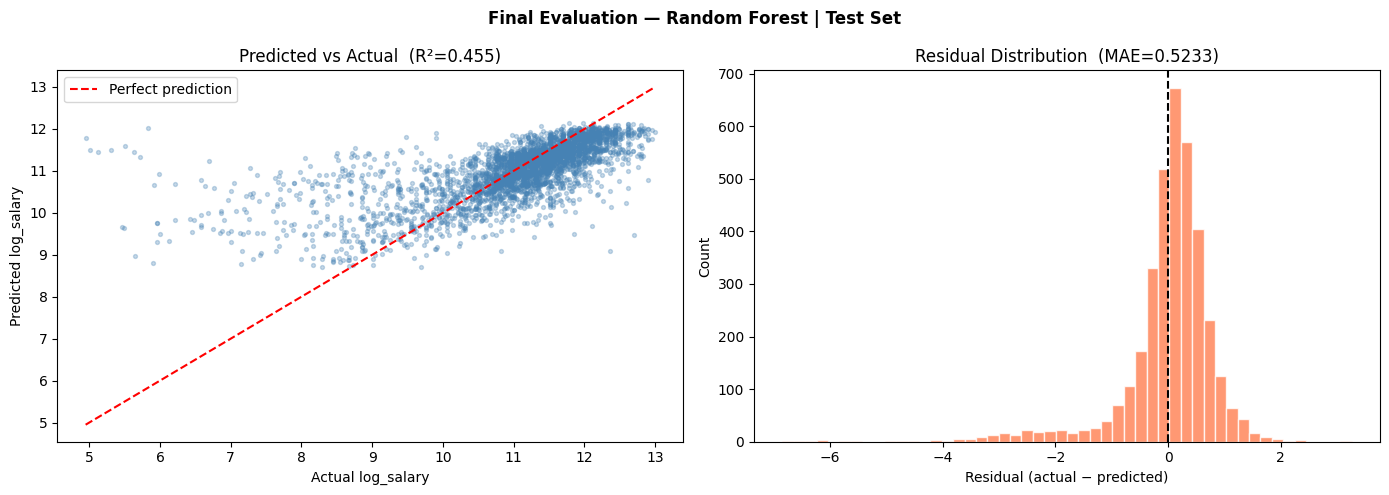

In [16]:
# ── Predicted vs Actual plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Final Evaluation — {winner_name} | Test Set', fontsize=12, fontweight='bold')

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred_log, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_log.min()), max(y_test.max(), y_pred_log.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log_salary')
axes[0].set_ylabel('Predicted log_salary')
axes[0].set_title(f'Predicted vs Actual  (R²={test_r2:.3f})')
axes[0].legend()

# Residuals distribution
residuals = y_test.values - y_pred_log
axes[1].hist(residuals, bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  (MAE={test_mae:.4f})')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'final_test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

## SHAP ANALYSIS — UsesAI Marginal Effect

UsesAI is the feature of interest. If its SHAP contribution is near zero or negative after all other features are controlled, the EDA salary premium does not survive the model — meaning the premium is explained by correlated variables, not AI adoption itself.

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature. This answers the core research question: **after the model has accounted for WorkExp, Region, DevType, Industry, and tech stack — what is the marginal contribution of `UsesAI` to salary?**

If `UsesAI` ranks low, the salary premium is explained by something else (experience, role type). If it ranks high, AI usage has genuine independent predictive power.

The cells below isolate UsesAI specifically. If the mean SHAP value for UsesAI=1 is positive, AI adoption independently contributes to higher salary predictions. If it is near zero or negative, the salary premium from EDA is fully explained by the other 102 features in the model. This is the test.

In [17]:
print('Computing SHAP values...')

# Extract the fitted model step from the pipeline
fitted_model = winner_pipeline.named_steps['model']

# Transform X_test through the preprocessor so SHAP sees the same space as the model
fitted_preprocessor = winner_pipeline.named_steps['preprocessor']
X_test_transformed   = fitted_preprocessor.transform(X_test)
X_train_transformed  = fitted_preprocessor.transform(X_train)

# Get feature names after transformation
try:
    feature_names = fitted_preprocessor.get_feature_names_out()
    # Clean up sklearn prefix (e.g. 'scale__WorkExp' → 'WorkExp')
    feature_names = [n.split('__')[-1] for n in feature_names]
except Exception:
    feature_names = X_train.columns.tolist()

# Use TreeExplainer for tree models, LinearExplainer for Ridge
if 'XGBoost' in winner_name or 'Random Forest' in winner_name:
    explainer = shap.TreeExplainer(fitted_model)
    # Use a sample for speed if dataset is large
    sample_size = min(2000, len(X_test_transformed))
    idx_sample  = np.random.choice(len(X_test_transformed), sample_size, replace=False)
    shap_values = explainer.shap_values(X_test_transformed[idx_sample])
    X_shap      = X_test_transformed[idx_sample]
else:
    # Linear model — use LinearExplainer with training data as background
    background  = shap.sample(X_train_transformed, 500)
    explainer   = shap.LinearExplainer(fitted_model, background)
    sample_size = min(2000, len(X_test_transformed))
    idx_sample  = np.random.choice(len(X_test_transformed), sample_size, replace=False)
    shap_values = explainer.shap_values(X_test_transformed[idx_sample])
    X_shap      = X_test_transformed[idx_sample]

print(f'SHAP values computed on {sample_size} test samples.')

Computing SHAP values...
SHAP values computed on 2000 test samples.


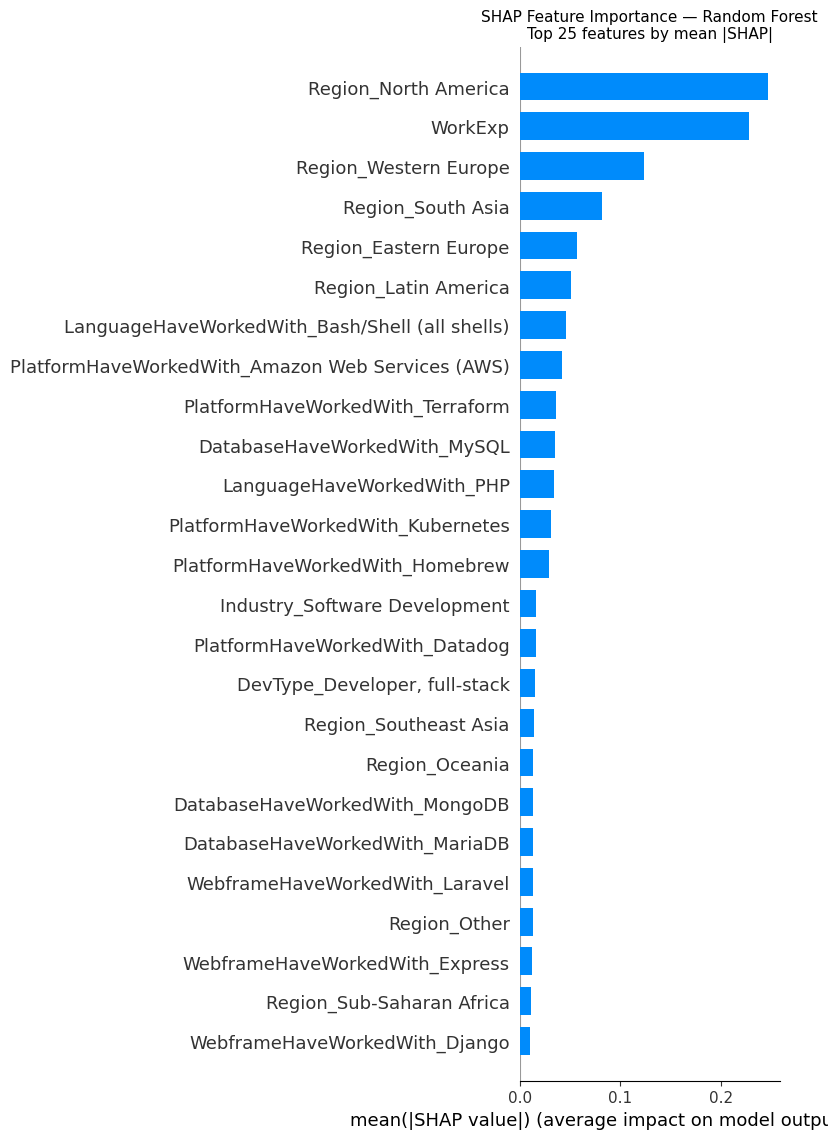

In [18]:
# ── SHAP Summary Plot (bar — global feature importance) ──────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    max_display=25,
    show=False
)
plt.title(f'SHAP Feature Importance — {winner_name}\nTop 25 features by mean |SHAP|', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_bar_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

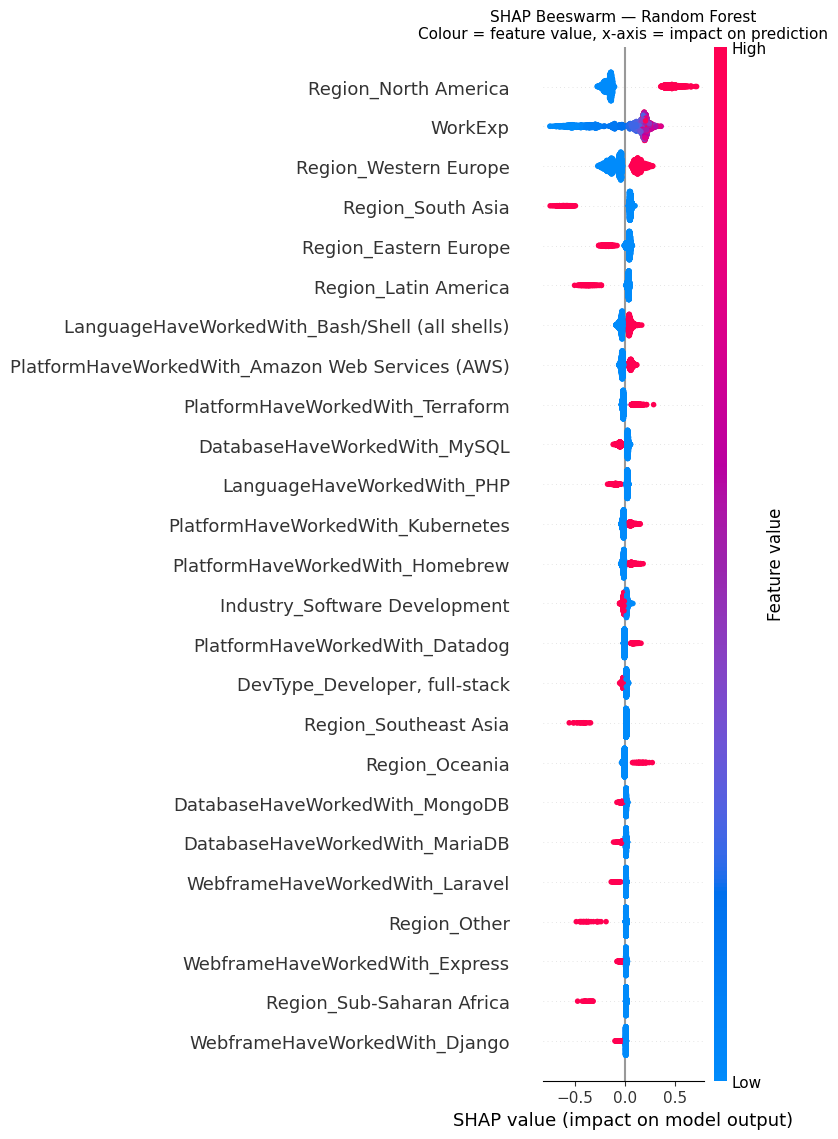

In [19]:
# ── SHAP Beeswarm Plot (direction and magnitude) ──────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    max_display=25,
    show=False
)
plt.title(f'SHAP Beeswarm — {winner_name}\nColour = feature value, x-axis = impact on prediction', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── UsesAI specific SHAP analysis ─────────────────────────────────────────
usesai_idx = None
for i, name in enumerate(feature_names):
    if 'UsesAI' in name:
        usesai_idx = i
        break

if usesai_idx is not None:
    usesai_shap = shap_values[:, usesai_idx]
    mean_abs_usesai = np.abs(usesai_shap).mean()

    # Rank UsesAI among all features
    mean_abs_all = np.abs(shap_values).mean(axis=0)
    rank         = int(np.sum(mean_abs_all > mean_abs_usesai)) + 1
    total_feats  = len(feature_names)

    # % of total SHAP attribution going to UsesAI
    pct_attribution = mean_abs_usesai / mean_abs_all.sum() * 100

    print('UsesAI — SHAP CONTRIBUTION ANALYSIS')
    print('=' * 55)
    print(f'  Mean |SHAP| for UsesAI : {mean_abs_usesai:.5f}')
    print(f'  Feature importance rank: {rank} / {total_feats}')
    print(f'  % of total attribution : {pct_attribution:.2f}%')
    print(f'  Direction (AI=1 mean)  : {usesai_shap[X_shap[:, usesai_idx] == 1].mean():+.5f}')
    print(f'  Direction (AI=0 mean)  : {usesai_shap[X_shap[:, usesai_idx] == 0].mean():+.5f}')
    print()

    # Interpret the finding
    if rank <= 5:
        print('  FINDING: UsesAI is a top-5 salary predictor. AI usage has strong')
        print('  independent salary signal above experience and other controls.')
    elif rank <= 15:
        print('  FINDING: UsesAI has moderate salary signal (top-15 feature).')
        print('  The premium exists but is not the dominant driver — experience')
        print('  and region likely rank above it.')
    else:
        print(f'  FINDING: UsesAI ranks {rank}/{total_feats} — weak salary signal.')
        print('  After controlling for confounders, AI usage explains little marginal variance.')
        print('  The observed salary premium is largely attributable to other factors.')

    print()
    conclusion = (
        f"After controlling for WorkExp, Region, DevType, Industry, and tech stack, "
        f"UsesAI ranks {rank}/{total_feats} in SHAP importance, accounting for "
        f"{pct_attribution:.1f}% of total model attribution. "
        f"AI users receive a SHAP contribution of "
        f"{usesai_shap[X_shap[:, usesai_idx] == 1].mean():+.4f} log-salary units on average."
    )
    print('  CONCLUSION:', conclusion)

    with open(os.path.join(config.RESULTS_DIR, 'usesai_shap_conclusion.txt'), 'w') as f:
        f.write(conclusion)
else:
    print('UsesAI column not found in transformed feature names — check preprocessor output.')

UsesAI — SHAP CONTRIBUTION ANALYSIS
  Mean |SHAP| for UsesAI : 0.00386
  Feature importance rank: 46 / 103
  % of total attribution : 0.28%
  Direction (AI=1 mean)  : -0.00102
  Direction (AI=0 mean)  : +0.00447

  FINDING: UsesAI ranks 46/103 — weak salary signal.
  After controlling for confounders, AI usage explains little marginal variance.
  The observed salary premium is largely attributable to other factors.

  CONCLUSION: After controlling for WorkExp, Region, DevType, Industry, and tech stack, UsesAI ranks 46/103 in SHAP importance, accounting for 0.3% of total model attribution. AI users receive a SHAP contribution of -0.0010 log-salary units on average.


<Figure size 800x500 with 0 Axes>

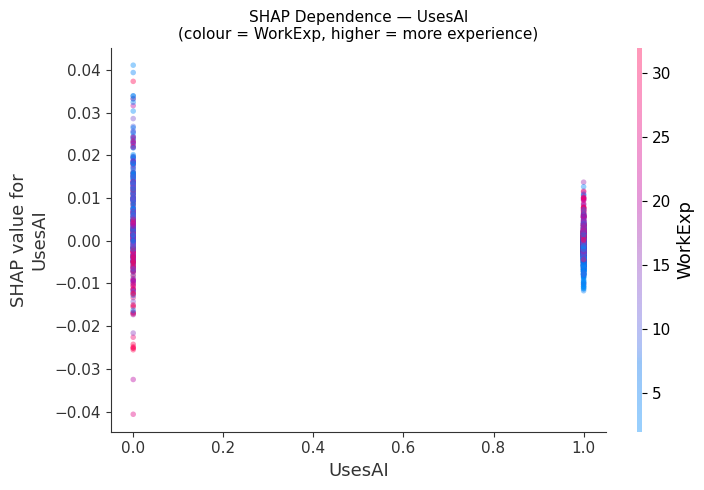

SHAP dependence plot saved. Colour gradient shows whether the UsesAI premium
varies by experience level — a colour gradient indicates an interaction effect.


In [21]:
# ── SHAP dependence plot for UsesAI (interaction with WorkExp) ───────────
if usesai_idx is not None:
    workexp_idx = next((i for i, n in enumerate(feature_names) if 'WorkExp' in n), None)

    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        usesai_idx,
        shap_values,
        X_shap,
        feature_names=feature_names,
        interaction_index=workexp_idx,
        show=False,
        alpha=0.4
    )
    plt.title('SHAP Dependence — UsesAI\n(colour = WorkExp, higher = more experience)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_usesai_dependence.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP dependence plot saved. Colour gradient shows whether the UsesAI premium')
    print('varies by experience level — a colour gradient indicates an interaction effect.')